# VP-SDE Diffusion

In [30]:
import math

import torch
import torch.nn as nn
from torch import optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt

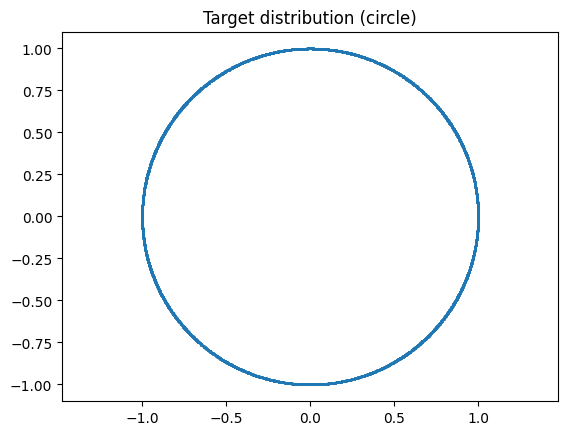

In [31]:
def generate_circle(radius=1.0, n_samples=5000):
    angles = np.random.uniform(0, 2*np.pi, n_samples)
    x = radius * np.cos(angles)
    y = radius * np.sin(angles)
    return np.stack([x, y], axis=1)

s = generate_circle(n_samples=5000)

plt.scatter(s[:, 0], s[:, 1], s=1)
plt.title('Target distribution (circle)')
plt.axis('equal')
plt.show()

In [32]:
def linear_alpha_bar(t, beta_min=0.1, beta_max=20.0):
    integral = beta_min * t + 0.5 * (beta_max - beta_min) * t ** 2
    return torch.clamp(torch.exp(-integral), min=1e-5, max=1.0 - 1e-5)

def linear_beta(t, beta_min=0.1, beta_max=20.0):
    return beta_min + (beta_max - beta_min) * t

def cosine_alpha_bar(t, s=0.008):
    angle = (t + s) / (1.0 + s) * math.pi / 2.0
    f0 = math.cos(s / (1.0 + s) * math.pi / 2.0) ** 2
    return torch.clamp(torch.cos(angle) ** 2 / f0, min=1e-5, max=1.0 - 1e-5)

def cosine_beta(t, s=0.008, beta_max=20.0):
    angle = (t + s) / (1.0 + s) * math.pi / 2.0
    beta = math.pi / (1.0 + s) * torch.tan(angle)
    return torch.clamp(beta, min=1e-6, max=beta_max)

SCHEDULES = {
    'linear': (linear_alpha_bar, linear_beta),
    'cosine': (cosine_alpha_bar, cosine_beta),
}

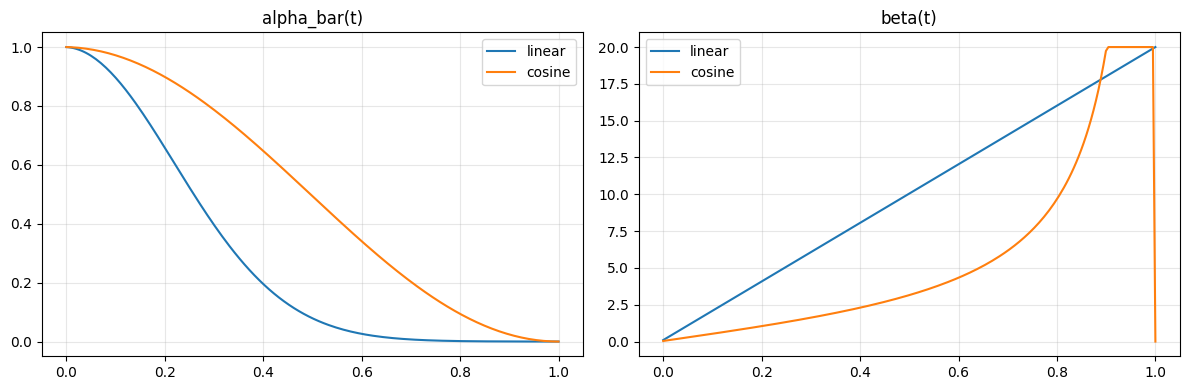

In [33]:
t_vals = torch.linspace(0, 1, 200)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for name, (ab_fn, b_fn) in SCHEDULES.items():
    axes[0].plot(t_vals.numpy(), ab_fn(t_vals).numpy(), label=name)
    axes[1].plot(t_vals.numpy(), b_fn(t_vals).numpy(), label=name)

axes[0].set_title('alpha_bar(t)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[1].set_title('beta(t)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
class Config:
    lr = 1e-3
    epochs = 2000
    batch_size = 512
    hidden_dim = 256
    num_timesteps = 1000
    data_samples = 5000

class ScoreModel(nn.Module):
    def __init__(self, config):
        super().__init__()

        self.config = config

        self.time_embed = nn.Sequential(
            nn.Linear(1, config.hidden_dim),
            nn.ReLU(),
            nn.Linear(config.hidden_dim, config.hidden_dim)
        )

        self.net = nn.Sequential(
            nn.Linear(2 + config.hidden_dim, config.hidden_dim),
            nn.ReLU(),
            nn.Linear(config.hidden_dim, 2)
        )

    def forward(self, x, t):
        t_embed = self.time_embed(t)
        x_input = torch.cat([x, t_embed], dim=1)
        return self.net(x_input)

In [34]:
def weight_uniform(alpha_bar, beta, t):
    return torch.ones_like(t)

def weight_snr(alpha_bar, beta, t):
    snr = alpha_bar / (1.0 - alpha_bar + 1e-5)
    return torch.clamp(snr, max=5.0)

def weight_snr_sqrt(alpha_bar, beta, t):
    snr = alpha_bar / (1.0 - alpha_bar + 1e-5)
    return torch.sqrt(torch.clamp(snr, max=5.0))

def weight_likelihood(alpha_bar, beta, t):
    return beta

WEIGHTS = {
    'uniform': weight_uniform,
    'snr': weight_snr,
    'snr_sqrt': weight_snr_sqrt,
    'likelihood': weight_likelihood,
}

In [35]:
class VPTrainer():
    def __init__(self, config, alpha_bar_fn, beta_fn, weight_fn):
        self.config = config
        self.device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
        self.alpha_bar_fn = alpha_bar_fn
        self.beta_fn = beta_fn
        self.weight_fn = weight_fn

        self.data = torch.tensor(s, dtype=torch.float32)

        self.dataset = TensorDataset(self.data)
        self.dataloader = DataLoader(self.dataset, batch_size=config.batch_size, shuffle=True)

        self.model = ScoreModel(config).to(self.device)
        self.optimizer = optim.Adam(self.model.parameters(), lr=config.lr)

    def train_epoch(self):
        self.model.train()
        total_loss = 0.0

        for (batch, ) in self.dataloader:
            batch = batch.to(self.device)

            t = torch.rand(batch.shape[0], 1, device=self.device)
            t = torch.clamp(t, min=1e-5, max=1.0 - 1e-5)

            alpha_bar = self.alpha_bar_fn(t)
            beta = self.beta_fn(t)
            epsilon = torch.randn_like(batch)

            x_t = torch.sqrt(alpha_bar) * batch + torch.sqrt(1.0 - alpha_bar) * epsilon

            pred_epsilon = self.model(x_t, t)

            w = self.weight_fn(alpha_bar, beta, t)
            loss = (w * (pred_epsilon - epsilon) ** 2).mean()

            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()

            total_loss += loss.item() * batch.shape[0]

        return total_loss / len(self.data)

    def run(self):
        losses = []
        for n in range(self.config.epochs):
            loss = self.train_epoch()
            losses.append(loss)
            if n % 500 == 0:
                print(f'Epoch {n}: Loss = {loss:.6f}')
        return losses

In [36]:
def sample_ddim(model, alpha_bar_fn, num_samples=1000, num_steps=50):
    device = next(model.parameters()).device
    model.eval()
    
    timesteps = torch.linspace(1, 0, num_steps + 1, device=device)
    
    with torch.no_grad():
        x = torch.randn(num_samples, 2, device=device)
        
        for i in range(num_steps):
            t = timesteps[i]
            t_next = timesteps[i + 1]
            
            t_tensor = torch.full((num_samples, 1), t, device=device)
            t_next_tensor = torch.full((num_samples, 1), t_next, device=device)
            
            alpha_bar_t = alpha_bar_fn(t_tensor)
            alpha_bar_t_next = alpha_bar_fn(t_next_tensor)
           
            pred_epsilon = model(x, t_tensor)
            
            sigma_t = torch.sqrt((1 - alpha_bar_t_next) / (1 - alpha_bar_t) * (1 - alpha_bar_t / alpha_bar_t_next) + 1e-8)
            
            x0_pred = (x - torch.sqrt(1 - alpha_bar_t + 1e-8) * pred_epsilon) / torch.sqrt(alpha_bar_t + 1e-8)
            
            x = torch.sqrt(alpha_bar_t_next) * x0_pred + torch.sqrt(1 - alpha_bar_t_next - sigma_t**2 + 1e-8) * pred_epsilon
            
            if i < num_steps - 1:
                x = x + sigma_t * torch.randn_like(x)
            
            x = torch.clamp(x, -2, 2)
        
        return x.cpu().numpy()

In [37]:
config = Config()
config.epochs = 1000
experiments = {}

weights_to_test = ['uniform', 'snr', 'snr_sqrt']

for weight_name in weights_to_test:
    print(f'\n=== Training with {weight_name} weights ===')
    
    ab_fn, b_fn = SCHEDULES['linear']
    w_fn = WEIGHTS[weight_name]
    
    trainer = VPTrainer(config, ab_fn, b_fn, w_fn)
    losses = trainer.run()
    
    samples = sample_ddim(
        trainer.model, ab_fn,
        num_samples=2000,
        num_steps=100
    )
    
    experiments[weight_name] = {
        'losses': losses,
        'samples': samples,
        'final_loss': losses[-1]
    }
    print(f'Final loss: {losses[-1]:.6f}')


=== Training with uniform weights ===
Epoch 0: Loss = 0.720152
Epoch 500: Loss = 0.174938
Final loss: 0.174655

=== Training with snr weights ===
Epoch 0: Loss = 0.938005
Epoch 500: Loss = 0.496513
Final loss: 0.594145

=== Training with snr_sqrt weights ===
Epoch 0: Loss = 0.554887
Epoch 500: Loss = 0.273524
Final loss: 0.314451


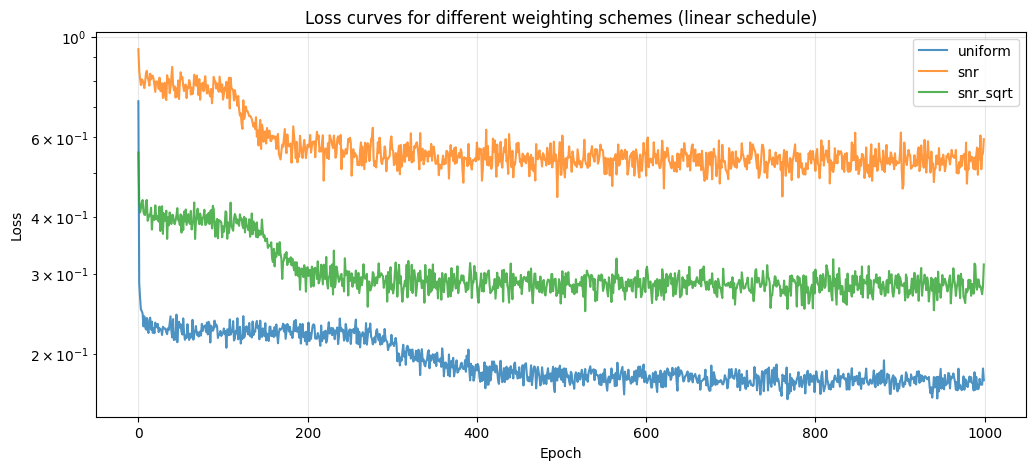

In [41]:
plt.figure(figsize=(12, 5))
for weight_name in weights_to_test:
    exp = experiments[weight_name]
    plt.plot(exp['losses'], label=weight_name, alpha=0.8)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss curves for different weighting schemes (linear schedule)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.show()

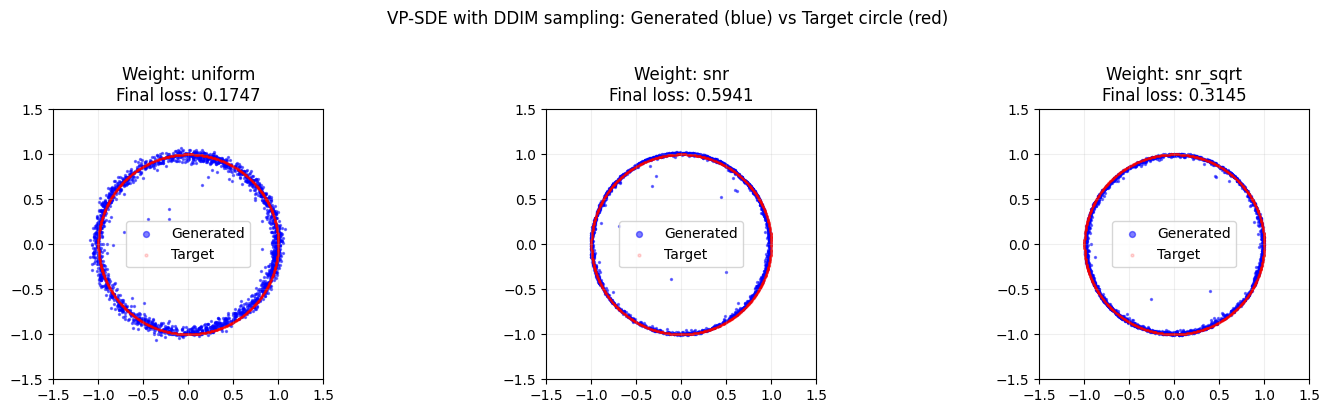

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, weight_name in enumerate(weights_to_test):
    exp = experiments[weight_name]
    ax = axes[idx]
    
    ax.scatter(exp['samples'][:, 0], exp['samples'][:, 1], 
               s=2, alpha=0.5, label='Generated', c='blue')
    ax.scatter(s[:, 0], s[:, 1], 
               s=0.5, alpha=0.15, label='Target', c='red')
    
    ax.set_title(f'Weight: {weight_name}\nFinal loss: {exp["final_loss"]:.4f}')
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    ax.set_aspect('equal')
    ax.legend(markerscale=3)
    ax.grid(True, alpha=0.2)

plt.suptitle('VP-SDE with DDIM sampling: Generated (blue) vs Target circle (red)', y=1.02)
plt.tight_layout()
plt.show()

In [43]:
def compute_jsd(samples, target, n_bins=30):
    H, _, _ = np.histogram2d(samples[:, 0], samples[:, 1], 
                              bins=n_bins, range=[[-1.5, 1.5], [-1.5, 1.5]])
    H_target, _, _ = np.histogram2d(target[:, 0], target[:, 1], 
                                     bins=n_bins, range=[[-1.5, 1.5], [-1.5, 1.5]])
    
    H = H / (H.sum() + 1e-8)
    H_target = H_target / (H_target.sum() + 1e-8)
    
    M = 0.5 * (H + H_target)
    jsd = 0.5 * (np.sum(H * np.log((H + 1e-8) / (M + 1e-8))) + 
                  np.sum(H_target * np.log((H_target + 1e-8) / (M + 1e-8))))
    return jsd

for weight_name in weights_to_test:
    exp = experiments[weight_name]
    jsd = compute_jsd(exp['samples'], s)
    print(f"{weight_name:12s} | JSD = {jsd:.4f} | Final loss = {exp['final_loss']:.4f}"

uniform      | JSD = 0.1185 | Final loss = 0.1747
snr          | JSD = 0.0718 | Final loss = 0.5941
snr_sqrt     | JSD = 0.0377 | Final loss = 0.3145


**Выводы**
Следует использовать snr_sqrt веса, так как они дают наилучшее качество генерации (JSD = 0.0377), несмотря на то, что loss не самый низкий. Это демонстрирует важность правильного взвешивания временных шагов в диффузионных моделях.
